In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from pathlib import Path
from jax import pmap
from flax.jax_utils import replicate
from flax.training.common_utils import shard
from PIL import Image
from huggingface_hub import notebook_login
import diffusers
from src.pipeline_flax_stable_diffusion import FlaxToyDiffusionPipeline

2024-03-17 17:15:10.223659: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
num_devices = jax.device_count()
device_type = jax.devices()[0].device_kind
print(f"Found {num_devices} JAX devices of type {device_type}.")
assert "TPU" in device_type, "Available device is not a TPU, please select TPU from Edit > Notebook settings > Hardware accelerator"
dtype = jnp.float32
pipeline, params = FlaxToyDiffusionPipeline.from_pretrained("sd-mnist")
params = replicate(params)

The config attributes {'safety_checker': [None, None]} were passed to FlaxToyDiffusionPipeline, but are not expected and will be ignored. Please verify your model_index.json configuration file.
Keyword arguments {'safety_checker': [None, None]} are not expected by FlaxToyDiffusionPipeline and will be ignored.


Found 8 JAX devices of type TPU v2.


In [3]:
num_inference_steps = 50
prng_seed = jax.random.PRNGKey(23)
prng_seed = jax.random.split(prng_seed, num_devices)
batch_size = 1
images = pipeline(batch_size, params, prng_seed, num_inference_steps,height=32,width=32,jit=True).images


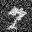

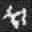

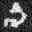

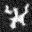

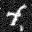

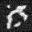

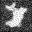

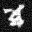

In [5]:
images = pipeline.numpy_to_pil(np.asarray(images.reshape((num_devices*batch_size,) + images.shape[-3:])))

for image in images:
    display(image)